In [1]:
import os
import copy
import random
import numpy as np
import pandas as pd

from PIL import Image
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms, models

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix

# Load the old CNN

In [2]:
# Use metal performance shaders (MPS) if available

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Usando dispositivo:", device)

#Load the model and configure for the device


model_path = "Models/Model_Exec_711_Epoch_150_cpu_portable_full.pt"

values = torch.load(model_path, map_location="cpu", weights_only=False)
model = values["modelo"]

model = model.to(device)
model.eval()

print("Modelo cargado correctamente")



Usando dispositivo: mps
Modelo cargado correctamente


# Capture the tensor and get the vector

In [3]:
#Tensor from model to vector[1024] extracter:

class CNNEmbeddingExtractor(nn.Module):
    def __init__(self, base_model):
        super().__init__()

        self.features = nn.ModuleList([
            nn.Sequential(*copy.deepcopy(block))
            for block in base_model.features
        ])

        self.second_level = copy.deepcopy(base_model.second_level)
        self.sizes = copy.deepcopy(base_model.sizes)

    def forward(self, image):
        x = image
        prev = -1
        pos = 0
        outputs = {}

        for i in range(len(self.features)):
            if i == 0 or i == 1:
                x = self.features[i](x)
                outputs[i] = x
            else:
                connections = self.second_level[pos:pos+prev]

                for c in range(len(connections)):
                    if connections[c] == 1:
                        skip_size = self.sizes[c][0]
                        req_size = x.shape[2]

                        if skip_size > req_size:
                            psize = skip_size - req_size + 1
                            pool = nn.MaxPool2d(kernel_size=psize, stride=1)
                            x2 = pool(outputs[c])

                        elif skip_size == req_size:
                            x2 = outputs[c]

                        else:
                            if (req_size - skip_size) % 2 == 0:
                                pad = int((req_size - skip_size) / 2)
                                padding = nn.ZeroPad2d(pad)
                                x2 = padding(outputs[c])
                            else:
                                pool = nn.MaxPool2d(kernel_size=2, stride=1, padding=1)
                                x2 = pool(outputs[c])
                                pad = int((req_size - skip_size - 1) / 2)
                                if pad > 0:
                                    padding = nn.ZeroPad2d(pad)
                                    x2 = padding(x2)

                        x = torch.cat((x, x2), axis=1)

                x = self.features[i](x)
                outputs[i] = x
                pos += prev

            prev += 1

        return torch.flatten(x, 1)

# Load the image and get the vector

In [4]:
#Transformer for the image

transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

In [5]:
#Obtain the vector for a real image

extractor = CNNEmbeddingExtractor(model)
extractor = extractor.to(device)
extractor.eval()

def get_embedding_from_image(image_path, extractor, transform):
    img = Image.open(image_path)
    x = transform(img).unsqueeze(0).to(device)  # [1,1,128,128]

    with torch.no_grad():
        #emb = extractor.forward(x) 
        emb = extractor(x)  # [1,1024]

    return emb.squeeze(0).detach().cpu()

# Create the clinical vector

In [6]:
#Check the csv
import pandas as pd

df = pd.read_csv("DataSet/dataset_maestro.csv")
print(df.shape)
print(df.columns.tolist())
df.head()

(365, 8)
['id', 'external_id', 'Clase', 'Dx Periapical', 'Sensibilidad', 'Percusión', 'Movilidad', 'Palpación']


,id,external_id,Clase,Dx Periapical,Sensibilidad,Percusión,Movilidad,Palpación
0,1. OD 22,radiografia_dataset_original/Pulpa Normal/1. O...,Pulpa Normal,Tejidos apicales normales,positivo,negativo,1,negativo
1,2. OD 25,radiografia_dataset_original/Pulpa Normal/2. O...,Pulpa Normal,Tejidos apicales normales,positivo,negativo,1,negativo
2,3. OD 14,radiografia_dataset_original/Pulpa Normal/3. O...,Pulpa Normal,Tejidos apicales normales,positivo,negativo,1,negativo
3,4. OD 25,radiografia_dataset_original/Pulpa Normal/4. O...,Pulpa Normal,Periodontitis apical sintomática,positivo,positivo,1,negativo
4,5. OD 27,radiografia_dataset_original/Pulpa Normal/5. O...,Pulpa Normal,Tejidos apicales normales,positivo,negativo,1,negativo


In [7]:
def build_clinical_vector(dx_periapical, sensibilidad, percusion, movilidad, palpacion):
    # Normalizar strings
    dx_periapical = str(dx_periapical).strip()
    sensibilidad = str(sensibilidad).strip().lower()
    percusion = str(percusion).strip().lower()
    movilidad = str(movilidad).strip()
    palpacion = str(palpacion).strip().lower()

    # Mapeo Dx Periapical
    dx_map = {
        "Periodontitis apical asintomática": [1, 0, 0, 0, 0],
        "Absceso apical crónico":            [0, 1, 0, 0, 0],
        "Periodontitis apical sintomática":  [0, 0, 1, 0, 0],
        "Tejidos apicales normales":         [0, 0, 0, 1, 0],
        "Absceso apical agudo":              [0, 0, 0, 0, 1],
    }

    # Binarias
    bin_map = {
        "positiva": 1.0,
        "positivo": 1.0,
        "negativa": 0.0,
        "negativo": 0.0,
    }

    # Movilidad
    movilidad_map = {
        "No valorable": [0, 0, 0],
        "1":            [1, 0, 0],
        "2":            [0, 1, 0],
        "3":            [0, 0, 1],  
    }

    if dx_periapical not in dx_map:
        raise ValueError(f"Dx Periapical no válido: {dx_periapical}")

    if sensibilidad not in bin_map:
        raise ValueError(f"Sensibilidad no válida: {sensibilidad}")

    if percusion not in bin_map:
        raise ValueError(f"Percusión no válida: {percusion}")

    if palpacion not in bin_map:
        raise ValueError(f"Palpación no válida: {palpacion}")

    if movilidad not in movilidad_map:
        raise ValueError(f"Movilidad no válida: {movilidad}")

    vector = (
        dx_map[dx_periapical]
        + [bin_map[sensibilidad]]
        + [bin_map[percusion]]
        + movilidad_map[movilidad]
        + [bin_map[palpacion]]
    )

    return torch.tensor(vector, dtype=torch.float32)

In [8]:
#This aren't the clases for the vector, this is for the final classification of the model.

class_to_idx = {
    "Necrosis Pulpar": 0,
    "Previamente iniciado": 1,
    "Previamente Tratado": 2,
    "Pulpa Normal": 3,
    "Pulpitis Irreversible Asintomática": 4,
    "Pulpitis Irreversible Sintomática": 5,
    "Pulpitis Reversible": 6,
}

In [9]:
def normalize_image_key(external_id):
    external_id = str(external_id).strip()
    prefix = "radiografia_dataset_original/"
    if external_id.startswith(prefix):
        return external_id[len(prefix):]
    return external_id

# Data Loader

In [10]:
# Check the images
from pathlib import Path

def build_image_path_dict(root_dir, valid_exts=None):
    if valid_exts is None:
        valid_exts = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

    root_dir = Path(root_dir)
    image_path_dict = {}
    failed_files = []

    all_files = sorted(root_dir.rglob("*"))

    for file_path in all_files:
        if file_path.is_file() and file_path.suffix.lower() in valid_exts:
            try:
                relative_key = str(file_path.relative_to(root_dir))
                relative_key = normalize_image_key(relative_key)

                image_path_dict[relative_key] = str(file_path)

            except Exception as e:
                failed_files.append((str(file_path), str(e)))

    return image_path_dict, failed_files

In [11]:
# Build the image path dictionary
root_dir = "DataSet/radiografia_dataset_original"

image_path_dict, failed_files = build_image_path_dict(
    root_dir=root_dir
)

print("Número de imágenes indexadas:", len(image_path_dict))
print("Número de archivos con error:", len(failed_files))

first_keys = list(image_path_dict.keys())[:10]

for k in first_keys:
    print("Clave:", k)
    print("Ruta:", image_path_dict[k])
    print()

if failed_files:
    print("Archivos con error:")
    for path, err in failed_files[:30]:
        print(path)
        print("Error:", err)
        print("-" * 50)
else:
    print("No hubo errores.")

Número de imágenes indexadas: 366
Número de archivos con error: 0
Clave: Necrosis Pulpar/1. OD 36.jpeg
Ruta: DataSet/radiografia_dataset_original/Necrosis Pulpar/1. OD 36.jpeg

Clave: Necrosis Pulpar/10. OD 16.jpg
Ruta: DataSet/radiografia_dataset_original/Necrosis Pulpar/10. OD 16.jpg

Clave: Necrosis Pulpar/100. OD 16.jpg
Ruta: DataSet/radiografia_dataset_original/Necrosis Pulpar/100. OD 16.jpg

Clave: Necrosis Pulpar/11. OD 17.jpg
Ruta: DataSet/radiografia_dataset_original/Necrosis Pulpar/11. OD 17.jpg

Clave: Necrosis Pulpar/12. OD 46.jpg
Ruta: DataSet/radiografia_dataset_original/Necrosis Pulpar/12. OD 46.jpg

Clave: Necrosis Pulpar/13. OD 14.jpg
Ruta: DataSet/radiografia_dataset_original/Necrosis Pulpar/13. OD 14.jpg

Clave: Necrosis Pulpar/14. OD 16.jpg
Ruta: DataSet/radiografia_dataset_original/Necrosis Pulpar/14. OD 16.jpg

Clave: Necrosis Pulpar/15. OD 13.jpg
Ruta: DataSet/radiografia_dataset_original/Necrosis Pulpar/15. OD 13.jpg

Clave: Necrosis Pulpar/16. OD 36.jpg
Ruta: D

In [12]:
# Create the samples

samples = []
errors = []

for idx, row in df.iterrows():
    try:
        image_key = normalize_image_key(row["external_id"])

        if image_key not in image_path_dict:
            raise KeyError(f"No se encontró imagen para: {image_key}")

        clinical_vector = build_clinical_vector(
            dx_periapical=row["Dx Periapical"],
            sensibilidad=row["Sensibilidad"],
            percusion=row["Percusión"],
            movilidad=row["Movilidad"],
            palpacion=row["Palpación"],
        )

        if row["Clase"] not in class_to_idx:
            raise KeyError(f"Clase no válida: {row['Clase']}")

        label = class_to_idx[row["Clase"]]

        samples.append({
            "image_key": image_key,
            "image_path": image_path_dict[image_key],   # ruta real de la imagen
            "clinical_vector": clinical_vector,         # [11]
            "label": label,                             # int
        })

    except Exception as e:
        errors.append({
            "row_idx": idx,
            "id": row.get("id", None),
            "external_id": row.get("external_id", None),
            "clase": row.get("Clase", None),
            "dx_periapical": row.get("Dx Periapical", None),
            "sensibilidad": row.get("Sensibilidad", None),
            "percusion": row.get("Percusión", None),
            "movilidad": row.get("Movilidad", None),
            "palpacion": row.get("Palpación", None),
            "error": str(e),
        })

print("Samples válidos:", len(samples))
print("Errores:", len(errors))

for err in errors:
    print("=" * 80)
    print(f"Fila: {err['row_idx']}")
    print(f"id: {err['id']}")
    print(f"external_id: {err['external_id']}")
    print(f"Clase: {err['clase']}")
    print(f"Dx Periapical: {err['dx_periapical']}")
    print(f"Sensibilidad: {err['sensibilidad']}")
    print(f"Percusión: {err['percusion']}")
    print(f"Movilidad: {err['movilidad']}")
    print(f"Palpación: {err['palpacion']}")
    print(f"Error: {err['error']}")

Samples válidos: 364
Errores: 1
Fila: 321
id: 26. OD 21
external_id: Previamente iniciado/26. OD 21.jpg
Clase: Previamente iniciado
Dx Periapical: Tejidos apicales normales
Sensibilidad: negativo
Percusión: negativo
Movilidad: 1
Palpación: negativo
Error: 'No se encontró imagen para: Previamente iniciado/26. OD 21.jpg'


In [13]:
# Data set Class for the stratification
from torch.utils.data import Dataset
from PIL import Image
import torch

class FullMultimodalFolderDataset(Dataset):
    def __init__(self, samples, transform=None):
        self.samples = samples
        self.transform = transform
        self.targets = [s["label"] for s in samples]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]

        image = Image.open(sample["image_path"]).convert("RGB")
        if self.transform is not None:
            image = self.transform(image)

        clinical = torch.tensor(sample["clinical_vector"], dtype=torch.float32)
        label = torch.tensor(sample["label"], dtype=torch.long)

        return image, clinical, label

In [14]:
# make the stratified splits

import numpy as np
from sklearn.model_selection import StratifiedShuffleSplit

def make_stratified_splits(targets, val_split=0.15, test_split=0.15, seed=42):
    y = np.array(targets)
    idx = np.arange(len(y))

    # train+val vs test
    sss_test = StratifiedShuffleSplit(
        n_splits=1,
        test_size=test_split,
        random_state=seed
    )
    trainval_idx, test_idx = next(sss_test.split(idx, y))

    # train vs val
    y_trainval = y[trainval_idx]
    val_rel = val_split / (1.0 - test_split)

    sss_val = StratifiedShuffleSplit(
        n_splits=1,
        test_size=val_rel,
        random_state=seed
    )
    train_rel, val_rel_idx = next(sss_val.split(trainval_idx, y_trainval))

    train_idx = trainval_idx[train_rel]
    val_idx = trainval_idx[val_rel_idx]

    return {
        "train_idx": train_idx,
        "val_idx": val_idx,
        "test_idx": test_idx,
    }

In [15]:
# Data loader

import torch
from torch.utils.data import DataLoader, Subset

def make_multimodal_dataloaders(
    ds,
    train_idx,
    val_idx,
    test_idx,
    batch_size=32,
    num_workers=2,
    seed=42,
):
    g = torch.Generator()
    g.manual_seed(seed)

    pin = torch.cuda.is_available()

    train_dl = DataLoader(
        Subset(ds, train_idx),
        batch_size=batch_size,
        shuffle=True,
        generator=g,
        num_workers=num_workers,
        pin_memory=pin,
    )

    val_dl = DataLoader(
        Subset(ds, val_idx),
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=pin,
    )

    test_dl = DataLoader(
        Subset(ds, test_idx),
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=pin,
    )

    return {
        "train": train_dl,
        "val": val_dl,
        "test": test_dl,
    }

In [16]:
# Use the Data loader
def load_data_module(
    samples,
    batch_size=32,
    val_split=0.15,
    test_split=0.15,
    seed=42,
    num_workers=0,
):
    ds = FullMultimodalFolderDataset(
        samples=samples,
        transform=transform
    )

    splits = make_stratified_splits(
        targets=ds.targets,
        val_split=val_split,
        test_split=test_split,
        seed=seed,
    )

    loaders = make_multimodal_dataloaders(
        ds=ds,
        train_idx=splits["train_idx"],
        val_idx=splits["val_idx"],
        test_idx=splits["test_idx"],
        batch_size=batch_size,
        num_workers=num_workers,
        seed=seed,
    )

    return {
        "dataset": ds,
        "loaders": loaders,
        "splits": splits,
    }

In [17]:
# Functions to show the distribution of classes in each split
from collections import Counter

def show_split_distribution(ds, split_idx, name, idx_to_class):
    labels = [ds.targets[i] for i in split_idx]
    counts = Counter(labels)
    total = len(labels)

    print(f"\n{name} total = {total}")
    for class_idx in sorted(idx_to_class.keys()):
        class_name = idx_to_class[class_idx]
        n = counts.get(class_idx, 0)
        pct = (n / total) * 100 if total > 0 else 0
        print(f"  {class_name:<35} {n:>3}  ({pct:>5.2f}%)")


def print_data_module_summary(data_module, class_to_idx):
    ds = data_module["dataset"]
    splits = data_module["splits"]

    train_idx = splits["train_idx"]
    val_idx = splits["val_idx"]
    test_idx = splits["test_idx"]

    idx_to_class = {v: k for k, v in class_to_idx.items()}

    print(f"Counts: {len(train_idx)} {len(val_idx)} {len(test_idx)}")

    show_split_distribution(ds, train_idx, "TRAIN", idx_to_class)
    show_split_distribution(ds, val_idx, "VAL", idx_to_class)
    show_split_distribution(ds, test_idx, "TEST", idx_to_class)

    all_idx = np.concatenate([train_idx, val_idx, test_idx])
    print("¿Índices únicos?", len(all_idx) == len(set(all_idx)))
    print("¿Algún índice fuera de rango?", max(all_idx) >= len(ds))
    

In [18]:
#Show the distribution of classes in each split
data_module = load_data_module(samples)

print_data_module_summary(data_module, class_to_idx)

Counts: 254 55 55

TRAIN total = 254
  Necrosis Pulpar                      70  (27.56%)
  Previamente iniciado                 17  ( 6.69%)
  Previamente Tratado                  30  (11.81%)
  Pulpa Normal                         43  (16.93%)
  Pulpitis Irreversible Asintomática   39  (15.35%)
  Pulpitis Irreversible Sintomática    52  (20.47%)
  Pulpitis Reversible                   3  ( 1.18%)

VAL total = 55
  Necrosis Pulpar                      15  (27.27%)
  Previamente iniciado                  4  ( 7.27%)
  Previamente Tratado                   6  (10.91%)
  Pulpa Normal                          9  (16.36%)
  Pulpitis Irreversible Asintomática    9  (16.36%)
  Pulpitis Irreversible Sintomática    11  (20.00%)
  Pulpitis Reversible                   1  ( 1.82%)

TEST total = 55
  Necrosis Pulpar                      15  (27.27%)
  Previamente iniciado                  4  ( 7.27%)
  Previamente Tratado                   7  (12.73%)
  Pulpa Normal                          9  (16

# Create the new model

In [19]:
#New clasifier for the fused model

class FusedClassifier(nn.Module):
    def __init__(self, input_dim=18443, hidden_dim1=256, hidden_dim2=64, num_classes=7):
        super().__init__()

        self.classifier = nn.Sequential(
            nn.Linear(input_dim, hidden_dim1),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim1, hidden_dim2),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim2, num_classes),
        )

    def forward(self, x):
        return self.classifier(x)

In [20]:
#Create the full model

class FullMultimodalDentalDeppGAModel(nn.Module):
    def __init__(self, embedding_extractor, fused_classifier):
        super().__init__()
        self.embedding_extractor = embedding_extractor
        self.fused_classifier = fused_classifier

    def forward(self, image, clinical_vector):
        embedding = self.embedding_extractor(image)          # [B, 1024]
        x = torch.cat([embedding, clinical_vector], dim=1)   # [B, 1035]
        logits = self.fused_classifier(x)                    # [B, 7]
        return logits

In [21]:
#Testing if the model exists

clinical_dim = len(samples[0]["clinical_vector"])
num_classes = len(class_to_idx)

print("clinical_dim:", clinical_dim)
print("num_classes:", num_classes)

extractor = CNNEmbeddingExtractor(model)

fused_classifier = FusedClassifier(
    num_classes=num_classes,
)

full_model = FullMultimodalDentalDeppGAModel(
    embedding_extractor=extractor,
    fused_classifier=fused_classifier,
).to(device)

print(full_model)

clinical_dim: 11
num_classes: 7
FullMultimodalDentalDeppGAModel(
  (embedding_extractor): CNNEmbeddingExtractor(
    (features): ModuleList(
      (0): Sequential(
        (0): Conv2d(1, 8, kernel_size=(5, 5), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): AvgPool2d(kernel_size=2, stride=2, padding=0)
      )
      (1): Sequential(
        (0): Conv2d(8, 8, kernel_size=(9, 9), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
      )
      (2): Sequential(
        (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
      )
      (3): Sequential(
        (0): Conv2d(16, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)

In [22]:
#Testing if the model can process a batch of data

train_loader = data_module["loaders"]["train"]

images, clinical_vectors, labels = next(iter(train_loader))

images = images.to(device)
clinical_vectors = clinical_vectors.to(device)
labels = labels.to(device)

with torch.no_grad():
    embedding = full_model.embedding_extractor(images)
    outputs = full_model(images, clinical_vectors)

print("images:", images.shape)
print("clinical_vectors:", clinical_vectors.shape)
print("embedding:", embedding.shape)
print("labels:", labels.shape)
print("outputs:", outputs.shape)

/var/folders/tl/kwq3tjcj1ys7lmb1pyf3jdd80000gn/T/ipykernel_64060/2383641742.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  clinical = torch.tensor(sample["clinical_vector"], dtype=torch.float32)


images: torch.Size([32, 1, 128, 128])
clinical_vectors: torch.Size([32, 11])
embedding: torch.Size([32, 18432])
labels: torch.Size([32])
outputs: torch.Size([32, 7])


In [23]:
images, clinical_vectors, labels = next(iter(train_loader))
print("labels en el batch:", labels)
print("unique labels:", labels.unique())
print("clinical_vectors muestra:", clinical_vectors[0])

labels en el batch: tensor([2, 0, 2, 0, 4, 0, 3, 0, 5, 5, 0, 5, 5, 1, 2, 1, 5, 0, 5, 3, 4, 5, 4, 1,
        1, 2, 5, 2, 6, 0, 2, 0])
unique labels: tensor([0, 1, 2, 3, 4, 5, 6])
clinical_vectors muestra: tensor([0., 0., 0., 1., 0., 0., 0., 1., 0., 0., 0.])


/var/folders/tl/kwq3tjcj1ys7lmb1pyf3jdd80000gn/T/ipykernel_64060/2383641742.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  clinical = torch.tensor(sample["clinical_vector"], dtype=torch.float32)


# Training the Full Model

In [24]:
#Training setup

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam([
    {"params": full_model.embedding_extractor.parameters(), "lr": 1e-6},  # CNN preentrenada: lr bajo
    {"params": full_model.fused_classifier.parameters(),   "lr": 1e-3},  # Clasificador nuevo: lr alto
], weight_decay=1e-4)

In [25]:
from collections import Counter
import torch

def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device,
    idx_to_class=None,
    print_batches=True,
):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    seen_labels = Counter()
    seen_preds = Counter()

    for batch_idx, (images, clinical_vectors, labels) in enumerate(loader):
        images = images.to(device, non_blocking=True)
        clinical_vectors = clinical_vectors.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        outputs = model(images, clinical_vectors)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        preds = outputs.argmax(dim=1)

        batch_correct = (preds == labels).sum().item()
        batch_total = labels.size(0)
        batch_acc = batch_correct / batch_total

        running_loss += loss.item() * batch_total
        correct += batch_correct
        total += batch_total

        labels_cpu = labels.detach().cpu().tolist()
        preds_cpu = preds.detach().cpu().tolist()

        seen_labels.update(labels_cpu)
        seen_preds.update(preds_cpu)

        if print_batches:
            print(f"\n===== Batch {batch_idx} =====")
            print(f"Loss: {loss.item():.4f} | Acc: {batch_acc:.4f}")
            print(f"Correct: {batch_correct}/{batch_total}")

            print("\nImagen por imagen:")
            for i, (true_id, pred_id) in enumerate(zip(labels_cpu, preds_cpu)):
                true_name = idx_to_class[true_id] if idx_to_class else str(true_id)
                pred_name = idx_to_class[pred_id] if idx_to_class else str(pred_id)

                mark = "✅" if true_id == pred_id else "❌"

                print(
                    f"{i:02d} {mark} "
                    f"real_train={true_id} ({true_name}) | "
                    f"pred={pred_id} ({pred_name})"
                )

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    print("\n===== Resumen entrenamiento =====")
    print(f"Train Loss: {epoch_loss:.4f}")
    print(f"Train Acc: {epoch_acc:.4f}")
    print(f"Correct total: {correct}/{total}")

    if idx_to_class is not None:
        print("\nClases reales vistas:")
        for class_idx, count in sorted(seen_labels.items()):
            print(f"  {class_idx} - {idx_to_class[class_idx]}: {count}")

        print("\nClases predichas:")
        for class_idx, count in sorted(seen_preds.items()):
            print(f"  {class_idx} - {idx_to_class[class_idx]}: {count}")

    return epoch_loss, epoch_acc

In [26]:
#Test if the model can train
train_loss, train_acc = train_one_epoch(
    full_model,
    data_module["loaders"]["train"],
    criterion,
    optimizer,
    device,
)

print(f"train_loss = {train_loss:.4f}")
print(f"train_acc  = {train_acc:.4f}")

/var/folders/tl/kwq3tjcj1ys7lmb1pyf3jdd80000gn/T/ipykernel_64060/2383641742.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  clinical = torch.tensor(sample["clinical_vector"], dtype=torch.float32)



===== Batch 0 =====
Loss: 1.9451 | Acc: 0.1562
Correct: 5/32

Imagen por imagen:
00 ❌ real_train=3 (3) | pred=2 (2)
01 ✅ real_train=2 (2) | pred=2 (2)
02 ❌ real_train=3 (3) | pred=5 (5)
03 ❌ real_train=4 (4) | pred=2 (2)
04 ✅ real_train=5 (5) | pred=5 (5)
05 ❌ real_train=5 (5) | pred=2 (2)
06 ❌ real_train=4 (4) | pred=2 (2)
07 ❌ real_train=3 (3) | pred=5 (5)
08 ❌ real_train=0 (0) | pred=6 (6)
09 ❌ real_train=5 (5) | pred=4 (4)
10 ❌ real_train=5 (5) | pred=2 (2)
11 ❌ real_train=0 (0) | pred=3 (3)
12 ❌ real_train=4 (4) | pred=2 (2)
13 ❌ real_train=4 (4) | pred=6 (6)
14 ✅ real_train=2 (2) | pred=2 (2)
15 ❌ real_train=3 (3) | pred=2 (2)
16 ❌ real_train=4 (4) | pred=2 (2)
17 ❌ real_train=5 (5) | pred=2 (2)
18 ❌ real_train=0 (0) | pred=3 (3)
19 ❌ real_train=3 (3) | pred=2 (2)
20 ❌ real_train=4 (4) | pred=2 (2)
21 ❌ real_train=5 (5) | pred=3 (3)
22 ❌ real_train=5 (5) | pred=2 (2)
23 ✅ real_train=3 (3) | pred=3 (3)
24 ❌ real_train=0 (0) | pred=3 (3)
25 ❌ real_train=2 (2) | pred=6 (6)
26 ✅ rea

In [27]:
from collections import Counter
import torch

def evaluate_one_epoch(
    model,
    loader,
    criterion,
    device,
    idx_to_class=None,
    print_batches=True,
    name="EVAL",
):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    seen_labels = Counter()
    seen_preds = Counter()

    with torch.no_grad():
        for batch_idx, (images, clinical_vectors, labels) in enumerate(loader):
            images = images.to(device, non_blocking=True)
            clinical_vectors = clinical_vectors.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images, clinical_vectors)
            loss = criterion(outputs, labels)

            preds = outputs.argmax(dim=1)

            batch_correct = (preds == labels).sum().item()
            batch_total = labels.size(0)
            batch_acc = batch_correct / batch_total

            running_loss += loss.item() * batch_total
            correct += batch_correct
            total += batch_total

            labels_cpu = labels.detach().cpu().tolist()
            preds_cpu = preds.detach().cpu().tolist()

            seen_labels.update(labels_cpu)
            seen_preds.update(preds_cpu)

            if print_batches:
                print(f"\n===== {name} Batch {batch_idx} =====")
                print(f"Loss: {loss.item():.4f} | Acc: {batch_acc:.4f}")
                print(f"Correct: {batch_correct}/{batch_total}")

                print("\nImagen por imagen:")
                for i, (true_id, pred_id) in enumerate(zip(labels_cpu, preds_cpu)):
                    true_name = idx_to_class[true_id] if idx_to_class else str(true_id)
                    pred_name = idx_to_class[pred_id] if idx_to_class else str(pred_id)

                    mark = "✅" if true_id == pred_id else "❌"

                    print(
                        f"{i:02d} {mark} "
                        f"real_eval={true_id} ({true_name}) | "
                        f"pred={pred_id} ({pred_name})"
                    )

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    print(f"\n===== Resumen {name} =====")
    print(f"{name} Loss: {epoch_loss:.4f}")
    print(f"{name} Acc: {epoch_acc:.4f}")
    print(f"Correct total: {correct}/{total}")

    if idx_to_class is not None:
        print("\nClases reales vistas:")
        for class_idx, count in sorted(seen_labels.items()):
            print(f"  {class_idx} - {idx_to_class[class_idx]}: {count}")

        print("\nClases predichas:")
        for class_idx, count in sorted(seen_preds.items()):
            print(f"  {class_idx} - {idx_to_class[class_idx]}: {count}")

    return epoch_loss, epoch_acc

In [43]:
val_loader = data_module["loaders"]["val"]
idx_to_class = {v: k for k, v in class_to_idx.items()}

val_loss, val_acc = evaluate_one_epoch(
    model=full_model,
    loader=val_loader,
    criterion=criterion,
    device=device,
    idx_to_class=idx_to_class,
    print_batches=True,
    name="VAL",
)

/var/folders/tl/kwq3tjcj1ys7lmb1pyf3jdd80000gn/T/ipykernel_64060/2383641742.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  clinical = torch.tensor(sample["clinical_vector"], dtype=torch.float32)



===== VAL Batch 0 =====
Loss: 1.4266 | Acc: 0.6250
Correct: 20/32

Imagen por imagen:
00 ✅ real_eval=0 (Necrosis Pulpar) | pred=0 (Necrosis Pulpar)
01 ✅ real_eval=3 (Pulpa Normal) | pred=3 (Pulpa Normal)
02 ✅ real_eval=0 (Necrosis Pulpar) | pred=0 (Necrosis Pulpar)
03 ❌ real_eval=0 (Necrosis Pulpar) | pred=4 (Pulpitis Irreversible Asintomática)
04 ❌ real_eval=0 (Necrosis Pulpar) | pred=4 (Pulpitis Irreversible Asintomática)
05 ❌ real_eval=5 (Pulpitis Irreversible Sintomática) | pred=4 (Pulpitis Irreversible Asintomática)
06 ✅ real_eval=0 (Necrosis Pulpar) | pred=0 (Necrosis Pulpar)
07 ❌ real_eval=4 (Pulpitis Irreversible Asintomática) | pred=1 (Previamente iniciado)
08 ✅ real_eval=5 (Pulpitis Irreversible Sintomática) | pred=5 (Pulpitis Irreversible Sintomática)
09 ✅ real_eval=4 (Pulpitis Irreversible Asintomática) | pred=4 (Pulpitis Irreversible Asintomática)
10 ❌ real_eval=1 (Previamente iniciado) | pred=5 (Pulpitis Irreversible Sintomática)
11 ❌ real_eval=4 (Pulpitis Irreversible A

In [29]:
import copy

def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs=20,
):
    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_acc = 0.0

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
    }

    for epoch in range(epochs):
        idx_to_class = {v: k for k, v in class_to_idx.items()}

        train_loss, train_acc = train_one_epoch(
            model=full_model,
            loader=train_loader,
            criterion=criterion,
            optimizer=optimizer,
            device=device,
            idx_to_class=idx_to_class,
            print_batches=True,
        )
        val_loss, val_acc = evaluate_one_epoch(
            model=full_model,
            loader=val_loader,
            criterion=criterion,
            device=device,
            idx_to_class=idx_to_class,
            print_batches=True,
            name="VAL",
        )
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch {epoch + 1}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc:.4f}"
        )

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_wts = copy.deepcopy(model.state_dict())

    # Fuera del loop: restaura los mejores pesos al final
    model.load_state_dict(best_model_wts)
    print("Mejor Val Acc:", best_val_acc)

    return model, history

In [30]:
train_loader = data_module["loaders"]["train"]
val_loader = data_module["loaders"]["val"]
test_loader = data_module["loaders"]["test"]

train_full_model, history = train_model(
    model=full_model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=50,
)

/var/folders/tl/kwq3tjcj1ys7lmb1pyf3jdd80000gn/T/ipykernel_64060/2383641742.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  clinical = torch.tensor(sample["clinical_vector"], dtype=torch.float32)



===== Batch 0 =====
Loss: 1.2504 | Acc: 0.5938
Correct: 19/32

Imagen por imagen:
00 ✅ real_train=0 (Necrosis Pulpar) | pred=0 (Necrosis Pulpar)
01 ✅ real_train=3 (Pulpa Normal) | pred=3 (Pulpa Normal)
02 ✅ real_train=2 (Previamente Tratado) | pred=2 (Previamente Tratado)
03 ❌ real_train=5 (Pulpitis Irreversible Sintomática) | pred=2 (Previamente Tratado)
04 ✅ real_train=5 (Pulpitis Irreversible Sintomática) | pred=5 (Pulpitis Irreversible Sintomática)
05 ❌ real_train=1 (Previamente iniciado) | pred=5 (Pulpitis Irreversible Sintomática)
06 ✅ real_train=5 (Pulpitis Irreversible Sintomática) | pred=5 (Pulpitis Irreversible Sintomática)
07 ✅ real_train=5 (Pulpitis Irreversible Sintomática) | pred=5 (Pulpitis Irreversible Sintomática)
08 ✅ real_train=5 (Pulpitis Irreversible Sintomática) | pred=5 (Pulpitis Irreversible Sintomática)
09 ✅ real_train=0 (Necrosis Pulpar) | pred=0 (Necrosis Pulpar)
10 ❌ real_train=5 (Pulpitis Irreversible Sintomática) | pred=3 (Pulpa Normal)
11 ✅ real_train=5 

In [31]:
from collections import Counter

def inspect_loader_classes(loader, idx_to_class, name):
    print(f"\n===== {name} =====")

    total_counter = Counter()

    for batch_idx, batch in enumerate(loader):
        images, clinical_vectors, labels = batch

        labels_list = labels.cpu().tolist()
        total_counter.update(labels_list)

        readable_labels = [idx_to_class[label] for label in labels_list]

        print(f"\nBatch {batch_idx}")
        print("Label ids:", labels_list)
        print("Classes:", readable_labels)

    print(f"\n{name} total distribution:")
    for class_idx in sorted(idx_to_class.keys()):
        class_name = idx_to_class[class_idx]
        count = total_counter.get(class_idx, 0)
        print(f"{class_idx} - {class_name}: {count}")


idx_to_class = {v: k for k, v in class_to_idx.items()}

inspect_loader_classes(train_loader, idx_to_class, "TRAIN")
inspect_loader_classes(val_loader, idx_to_class, "VAL")
inspect_loader_classes(test_loader, idx_to_class, "TEST")


===== TRAIN =====

Batch 0
Label ids: [4, 2, 2, 1, 1, 2, 3, 0, 5, 5, 2, 4, 3, 5, 5, 5, 0, 5, 5, 4, 0, 5, 2, 2, 5, 3, 0, 4, 1, 0, 5, 2]
Classes: ['Pulpitis Irreversible Asintomática', 'Previamente Tratado', 'Previamente Tratado', 'Previamente iniciado', 'Previamente iniciado', 'Previamente Tratado', 'Pulpa Normal', 'Necrosis Pulpar', 'Pulpitis Irreversible Sintomática', 'Pulpitis Irreversible Sintomática', 'Previamente Tratado', 'Pulpitis Irreversible Asintomática', 'Pulpa Normal', 'Pulpitis Irreversible Sintomática', 'Pulpitis Irreversible Sintomática', 'Pulpitis Irreversible Sintomática', 'Necrosis Pulpar', 'Pulpitis Irreversible Sintomática', 'Pulpitis Irreversible Sintomática', 'Pulpitis Irreversible Asintomática', 'Necrosis Pulpar', 'Pulpitis Irreversible Sintomática', 'Previamente Tratado', 'Previamente Tratado', 'Pulpitis Irreversible Sintomática', 'Pulpa Normal', 'Necrosis Pulpar', 'Pulpitis Irreversible Asintomática', 'Previamente iniciado', 'Necrosis Pulpar', 'Pulpitis Irreve

/var/folders/tl/kwq3tjcj1ys7lmb1pyf3jdd80000gn/T/ipykernel_64060/2383641742.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  clinical = torch.tensor(sample["clinical_vector"], dtype=torch.float32)



Batch 1
Label ids: [0, 0, 6, 0, 5, 5, 0, 0, 4, 2, 3, 5, 4, 5, 0, 0, 4, 6, 4, 1, 4, 5, 5, 3, 3, 3, 2, 3, 5, 3, 0, 0]
Classes: ['Necrosis Pulpar', 'Necrosis Pulpar', 'Pulpitis Reversible', 'Necrosis Pulpar', 'Pulpitis Irreversible Sintomática', 'Pulpitis Irreversible Sintomática', 'Necrosis Pulpar', 'Necrosis Pulpar', 'Pulpitis Irreversible Asintomática', 'Previamente Tratado', 'Pulpa Normal', 'Pulpitis Irreversible Sintomática', 'Pulpitis Irreversible Asintomática', 'Pulpitis Irreversible Sintomática', 'Necrosis Pulpar', 'Necrosis Pulpar', 'Pulpitis Irreversible Asintomática', 'Pulpitis Reversible', 'Pulpitis Irreversible Asintomática', 'Previamente iniciado', 'Pulpitis Irreversible Asintomática', 'Pulpitis Irreversible Sintomática', 'Pulpitis Irreversible Sintomática', 'Pulpa Normal', 'Pulpa Normal', 'Pulpa Normal', 'Previamente Tratado', 'Pulpa Normal', 'Pulpitis Irreversible Sintomática', 'Pulpa Normal', 'Necrosis Pulpar', 'Necrosis Pulpar']

Batch 2
Label ids: [3, 1, 5, 0, 0, 2, 0,

In [32]:
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)

@torch.no_grad()
def get_predictions(model, loader, device):
    model.eval()

    all_preds = []
    all_targets = []

    for images, clinical_vectors, labels in loader:
        images = images.to(device, non_blocking=True)
        clinical_vectors = clinical_vectors.to(device, non_blocking=True)

        logits = model(images, clinical_vectors)
        preds = torch.argmax(logits, dim=1).cpu().numpy()

        all_preds.extend(preds)
        all_targets.extend(labels.numpy())

    all_preds = np.array(all_preds)
    all_targets = np.array(all_targets)

    return all_targets, all_preds


def evaluate_classification_model(model, loader, device, idx_to_class):
    y_true, y_pred = get_predictions(model, loader, device)

    acc = accuracy_score(y_true, y_pred)

    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )

    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )

    labels = sorted(idx_to_class.keys())
    target_names = [idx_to_class[i] for i in labels]

    cm = confusion_matrix(y_true, y_pred, labels=labels)

    report = classification_report(
        y_true,
        y_pred,
        labels=labels,
        target_names=target_names,
        zero_division=0,
    )

    results = {
        "accuracy": acc,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "precision_weighted": precision_weighted,
        "recall_weighted": recall_weighted,
        "f1_weighted": f1_weighted,
        "confusion_matrix": cm,
        "classification_report": report,
        "y_true": y_true,
        "y_pred": y_pred,
    }

    return results

In [33]:
idx_to_class = {v: k for k, v in class_to_idx.items()}

results = evaluate_classification_model(
    model=train_full_model,
    loader=data_module["loaders"]["test"],
    device=device,
    idx_to_class=idx_to_class,
)

print(f"Accuracy           : {results['accuracy']:.4f}")
print(f"Precision macro    : {results['precision_macro']:.4f}")
print(f"Recall macro       : {results['recall_macro']:.4f}")
print(f"F1 macro           : {results['f1_macro']:.4f}")
print(f"Precision weighted : {results['precision_weighted']:.4f}")
print(f"Recall weighted    : {results['recall_weighted']:.4f}")
print(f"F1 weighted        : {results['f1_weighted']:.4f}")

print("\nClassification report:\n")
print(results["classification_report"])

print("Confusion matrix:\n")
print(results["confusion_matrix"])

/var/folders/tl/kwq3tjcj1ys7lmb1pyf3jdd80000gn/T/ipykernel_64060/2383641742.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  clinical = torch.tensor(sample["clinical_vector"], dtype=torch.float32)


Accuracy           : 0.2909
Precision macro    : 0.1743
Recall macro       : 0.2204
F1 macro           : 0.1938
Precision weighted : 0.2326
Recall weighted    : 0.2909
F1 weighted        : 0.2574

Classification report:

                                    precision    recall  f1-score   support

                   Necrosis Pulpar       0.28      0.33      0.30        15
              Previamente iniciado       0.00      0.00      0.00         4
               Previamente Tratado       0.00      0.00      0.00         7
                      Pulpa Normal       0.54      0.78      0.64         9
Pulpitis Irreversible Asintomática       0.22      0.25      0.24         8
 Pulpitis Irreversible Sintomática       0.18      0.18      0.18        11
               Pulpitis Reversible       0.00      0.00      0.00         1

                          accuracy                           0.29        55
                         macro avg       0.17      0.22      0.19        55
                 

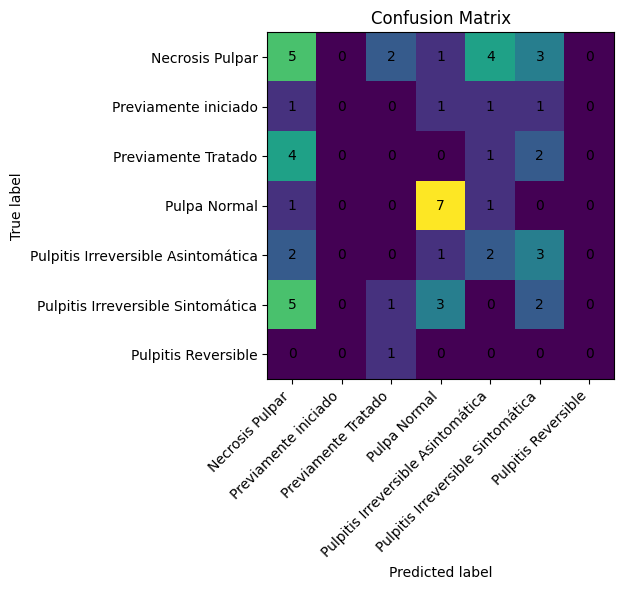

In [34]:
import matplotlib.pyplot as plt

def plot_confusion_matrix(cm, idx_to_class):
    labels = [idx_to_class[i] for i in sorted(idx_to_class.keys())]

    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(cm)

    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))

    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_yticklabels(labels)

    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_title("Confusion Matrix")

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha="center", va="center")

    plt.tight_layout()
    plt.show()

plot_confusion_matrix(results["confusion_matrix"], idx_to_class)


In [35]:
from collections import Counter

test_loader = data_module["loaders"]["test"]

loader_labels = []

for images, clinical_vectors, labels in test_loader:
    loader_labels.extend(labels.numpy().tolist())

print("Total labels desde test_loader:", len(loader_labels))
print("Distribución desde test_loader:")

for class_idx, count in sorted(Counter(loader_labels).items()):
    print(class_idx, idx_to_class[class_idx], count)

/var/folders/tl/kwq3tjcj1ys7lmb1pyf3jdd80000gn/T/ipykernel_64060/2383641742.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  clinical = torch.tensor(sample["clinical_vector"], dtype=torch.float32)


Total labels desde test_loader: 55
Distribución desde test_loader:
0 Necrosis Pulpar 15
1 Previamente iniciado 4
2 Previamente Tratado 7
3 Pulpa Normal 9
4 Pulpitis Irreversible Asintomática 8
5 Pulpitis Irreversible Sintomática 11
6 Pulpitis Reversible 1
